<a href="https://colab.research.google.com/github/Kevantech/python-coursework/blob/main/Self_study_try_it_activity_23_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 23.2: Kernel PCA

Kernel PCA is an advanced form of PCA that helps uncover complex, non-linear patterns in data. Unlike standard PCA, which works in the original feature space, kernel PCA uses a kernel function (such as polynomial or radial basis function) to indirectly map the data into a higher-dimensional space. This approach, known as the kernel trick, allows the algorithm to capture curved or layered structures without explicitly performing the transformation. Kernel PCA can effectively reduce dimensionality even when linear methods fall short, by analysing the resulting kernel matrix.

Below is the same data set on stocks over five years, plotted using the linear kernel, along with three new non-linear kernels built into scikit-learn. Note the significant differences in the first two components of the PCA projections that are now calculated.

With this type of analysis, it may not always be clear which kernel to use – usually, evaluating the performance of the method you attempt is the most crucial consideration. Knowing about the different possible kernels for PCA is an important additional tool that can be leveraged to solve problems that cannot be tackled otherwise.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
#Import the necessary libraries
import numpy.random as rand
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In this notebook, you initially work with a data set comprising S&P 500 stock prices over the past five years.

In [19]:
#df = pd.read_csv("data/all_stocks_5yr.csv")
df = pd.read_csv("all_stocks_5yr.csv")
names = df["Name"].unique()
range(len(df[ df["Name"] == names[0]]["close"]))
l = len(df[ df["Name"] == names[0]]["close"])
data = pd.DataFrame(index = range(l), columns= names)

for name in names:
    x = df[ df["Name"] == name]["close"]
    if x.isnull().any() or len(x) != l:
        data = data.drop(columns= name)
    else:
        data[name] = np.array(x)

data.head()


,AAL,AAPL,AAP,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,...,XLNX,XL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
0,14.75,67.8542,78.90,36.25,46.89,34.41,73.31,39.12,45.70,30.22,...,37.51,28.24,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
1,14.46,68.5614,78.39,35.85,46.76,34.26,73.07,38.64,46.08,30.28,...,37.46,28.31,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2,14.27,66.8428,78.60,35.42,46.96,34.30,73.37,38.89,46.27,30.81,...,37.58,28.41,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
3,14.66,66.7156,78.97,35.27,46.64,34.46,73.56,38.81,46.26,31.16,...,37.80,28.42,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
4,13.99,66.6556,78.84,36.57,46.77,34.70,73.13,38.61,46.54,31.40,...,38.44,28.22,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


### Answer:
scaler = StandardScaler().fit(data)   #Fit the scaler: computes mean and std of each stock

data_scaled = scaler.transform(data)  #Transform: rescale each stock to mean 0, std 1

In [20]:
### Type your answer here


Kernel PCA is applied using four different kernels to reduce dimensionality and visualise the transformed data.

Kernel PCA is initialised with ten components using four kernels: linear, RBF, polynomial and cosine.

Each kernel-specific kernel PCA object fits and transforms the scaled data using `fit_transform()`.

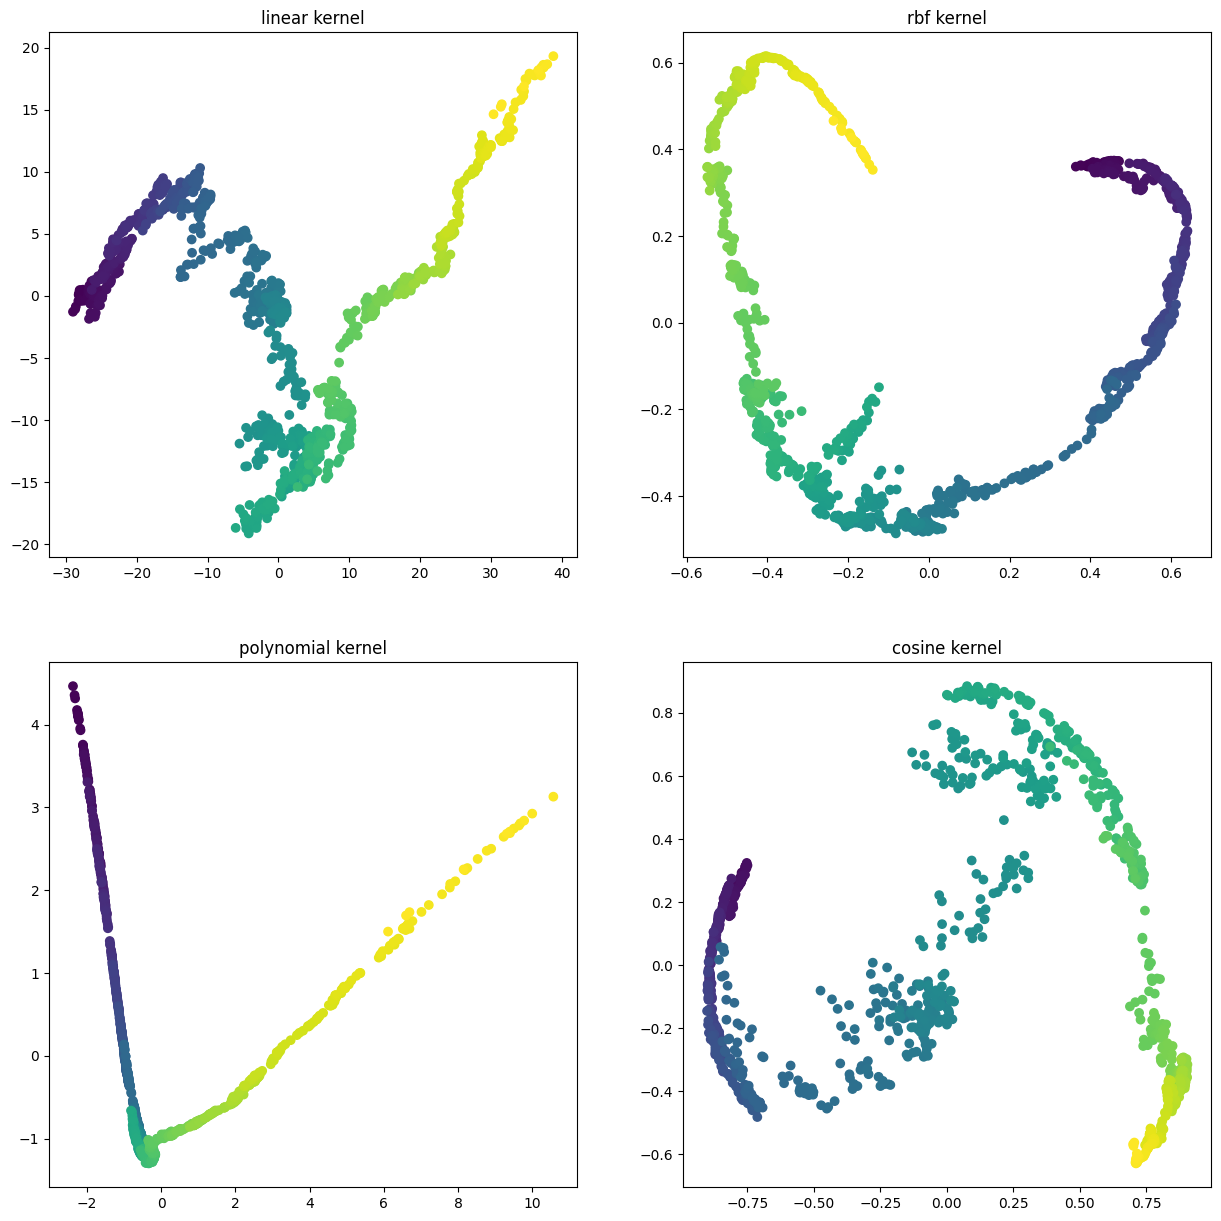

In [21]:
from sklearn.decomposition import KernelPCA

scaler = StandardScaler().fit(data)
data_scaled = scaler.transform(data)

kpca_linear = KernelPCA(n_components = 10, kernel = "linear")
kpca_rbf = KernelPCA(n_components = 10, kernel = "rbf")
kpca_poly = KernelPCA(n_components= 10, kernel= "poly")
kpca_cos = KernelPCA(n_components= 10, kernel= "cosine")

X_linear = kpca_linear.fit_transform(data_scaled)
X_rbf = kpca_rbf.fit_transform(data_scaled)
X_poly = kpca_poly.fit_transform(data_scaled)
X_cos = kpca_cos.fit_transform(data_scaled)


fig, axs = plt.subplots(2,2, figsize = (15, 15))
axs[0, 0].scatter(X_linear[:,0],X_linear[:, 1], c = np.arange(l)/l)
axs[0, 0].set_title("linear kernel")
axs[0, 1].scatter(X_rbf[:, 0], X_rbf[:, 1], c = np.arange(l)/l)
axs[0, 1].set_title("rbf kernel")
axs[1, 0].scatter(X_poly[:,0],X_poly[:, 1], c = np.arange(l)/l)
axs[1, 0].set_title("polynomial kernel")
axs[1, 1].scatter(X_cos[:,0],X_cos[:, 1], c = np.arange(l)/l)
axs[1, 1].set_title("cosine kernel")
plt.show()

### Answer:
X_linear = kpca_linear.fit_transform(iris_df)
X_rbf = kpca_rbf.fit_transform(iris_df)
X_poly = kpca_poly.fit_transform(iris_df)
X_cos = kpca_cos.fit_transform(iris_df)

fig, axs = plt.subplots(2,2, figsize = (15, 15))
axs[0, 0].scatter(X_linear[:,0],X_linear[:, 1], c = iris["target"])
axs[0, 0].set_title("linear kernel")
axs[0, 1].scatter(X_rbf[:, 0], X_rbf[:, 1], c = iris["target"])
axs[0, 1].set_title("rbf kernel")
axs[1, 0].scatter(X_poly[:,0],X_poly[:,1], c = iris["target"])
axs[1, 0].set_title("polynomial kernel")
axs[1, 1].scatter(X_cos[:,0],X_cos[:,1], c = iris["target"])
axs[1, 1].set_title("cosine kernel")
plt.show()

In [22]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(data= iris['data'],
                     columns= iris['feature_names'])

print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


### Answer:
scaler = StandardScaler().fit(iris_df)   #Fit the scaler on the iris data

iris_scaled = scaler.transform(iris_df)  #Rescale each feature to mean 0, std 1

TypeError: 'NoneType' object is not subscriptable

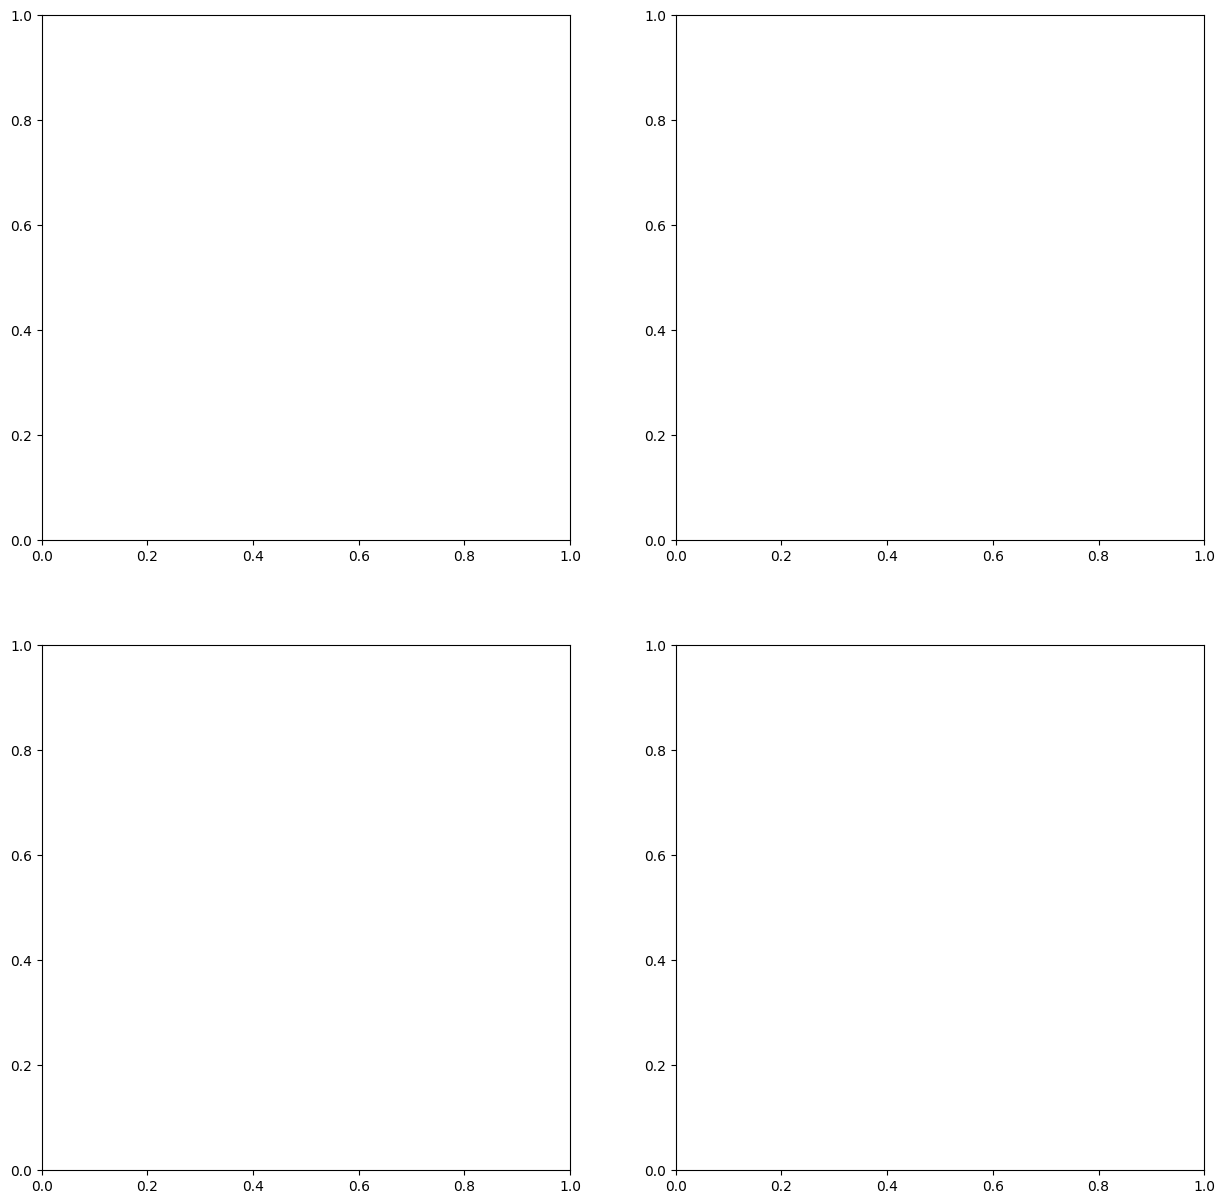

In [23]:
### Type in your answer here
X_linear = None
X_rbf = None
X_poly = None
X_cos = None

fig, axs = plt.subplots(2,2, figsize = (15, 15))
axs[0, 0].scatter(X_linear[:,0],X_linear[:, 1], c = iris["target"])
axs[0, 0].set_title("linear kernel")
axs[0, 1].scatter(X_rbf[:, 0], X_rbf[:, 1], c = iris["target"])
axs[0, 1].set_title("rbf kernel")
axs[1, 0].scatter(X_poly[:,0],X_poly[:,1], c = iris["target"])
axs[1, 0].set_title("polynomial kernel")
axs[1, 1].scatter(X_cos[:,0],X_cos[:,1], c = iris["target"])
axs[1, 1].set_title("cosine kernel")
plt.show()

### Answer:
X_linear_scaled = kpca_linear.fit_transform(iris_scaled)
X_rbf_scaled = kpca_rbf.fit_transform(iris_scaled)
X_poly_scaled = kpca_poly.fit_transform(iris_scaled)
X_cos_scaled = kpca_cos.fit_transform(iris_scaled)

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

axs[0, 0].scatter(X_linear_scaled[:, 0], X_linear_scaled[:, 1], c=iris["target"])
axs[0, 0].set_title("Linear Kernel")

axs[0, 1].scatter(X_rbf_scaled[:, 0], X_rbf_scaled[:, 1], c=iris["target"])
axs[0, 1].set_title("RBF Kernel")

axs[1, 0].scatter(X_poly_scaled[:, 0], X_poly_scaled[:, 1], c=iris["target"])
axs[1, 0].set_title("Polynomial Kernel")

axs[1, 1].scatter(X_cos_scaled[:, 0], X_cos_scaled[:, 1], c=iris["target"])
axs[1, 1].set_title("Cosine Kernel")

plt.tight_layout()
plt.show()

In [ ]:
### Type in your answers here
scaler = None

iris_scaled = None

### Type your answers here.

**Answer:**

Applying `StandardScaler` before kernel PCA changes the geometry of the data the kernels operate on, and this clearly affects how well the three iris species separate:

* **Without scaling**, the features have very different magnitudes (petal length ranges over several centimetres while petal width varies much less). Distance-based kernels — especially the **RBF kernel**, which depends on Euclidean distances between points — are dominated by the large-magnitude features. On the unscaled data the linear, polynomial and cosine projections still show reasonable structure (iris is nearly linearly separable), but the separation is driven almost entirely by petal length, and the RBF projection tends to compress points in an uneven way.

* **With scaling**, every feature contributes equally to the kernel computations. The clusters become more balanced and rounded, the boundary between *versicolor* and *virginica* is cleaner in the RBF projection, and *setosa* remains clearly isolated in all four kernels. The linear and cosine results change less dramatically (cosine is inherently less scale-sensitive because it normalises vector lengths), but the distance-based kernels benefit visibly.

* **Which is better:** the **scaled approach yields the better and more trustworthy results**. Even where the unscaled plots look acceptable, that separation reflects the arbitrary units of the measurements rather than genuine structure. Standardising ensures the kernels compare all four measurements on equal footing, which is the correct methodology whenever features are measured on different scales. Among the kernels, the linear and RBF projections on the scaled data give the clearest separation of the three species — a reminder that iris is a largely linearly separable data set, so a highly non-linear kernel is not strictly necessary here.

In [ ]:


X_linear_scaled = None
X_rbf_scaled = None
X_poly_scaled = None
X_cos_scaled = None

fig, axs = plt.subplots(2, 2, figsize=(15, 15))


axs[0, 0].scatter(X_linear_scaled[:, 0], X_linear_scaled[:, 1], c=iris["target"])

axs[0, 0].set_title("Linear Kernel")


axs[0, 1].scatter(X_rbf_scaled[:, 0], X_rbf_scaled[:, 1], c=iris["target"])

axs[0, 1].set_title("RBF Kernel")


axs[1, 0].scatter(X_poly_scaled[:, 0], X_poly_scaled[:, 1], c=iris["target"])

axs[1, 0].set_title("Polynomial Kernel")


axs[1, 1].scatter(X_cos_scaled[:, 0], X_cos_scaled[:, 1], c=iris["target"])

axs[1, 1].set_title("Cosine Kernel")


plt.tight_layout()

plt.show()



## To-do 5:
How does applying `StandardScaler` to the iris data set before kernel PCA affect the separation of species in the resulting visualisations, and which approach yields better results?

### Type your answers here.

